# Dataset:
##### •	Name: Fracture Multi-Region X-ray Data.
##### •	It is an X-ray image of human bones.


## Exploratory Data Analysis (EDA)

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

## Specify the file path and read the main folders.
#### In medical data, the data is divided into test data and training data.

In [32]:
base_path = r'C:\Users\HP\Downloads\archive (26)'
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/ (Files: {len(files)})')

archive (26)/ (Files: 1)
    Bone_Fracture_Binary_Classification/ (Files: 0)
        Bone_Fracture_Binary_Classification/ (Files: 0)
            test/ (Files: 0)
                fractured/ (Files: 237)
                not fractured/ (Files: 267)
            train/ (Files: 0)
                fractured/ (Files: 4593)
                not fractured/ (Files: 4625)
            val/ (Files: 0)
                fractured/ (Files: 336)
                not fractured/ (Files: 490)


# Data Distribution
### First, convert all the data into a Data Frame.

In [33]:
data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]
            region = path_parts[-2]
            data_list.append({'Region': region, 'Label': label})
df = pd.DataFrame(data_list)

### Knowing the number of images in each file and their percentage of the total data
### This reduces the risk of model bias.

In [34]:
summary = df.groupby(['Region', 'Label']).size().reset_index(name='Count')
summary['Percentage'] = (summary['Count'] / summary['Count'].sum()) * 100
print("*"*3,"Data distribution summary ","*"*3)
print(summary)

*** Data distribution summary  ***
  Region          Label  Count  Percentage
0   test      fractured    237    2.246871
1   test  not fractured    267    2.531286
2  train      fractured   4593   43.543800
3  train  not fractured   4625   43.847175
4    val      fractured    336    3.185438
5    val  not fractured    490    4.645430


### A diagram illustrating the data distribution mechanism

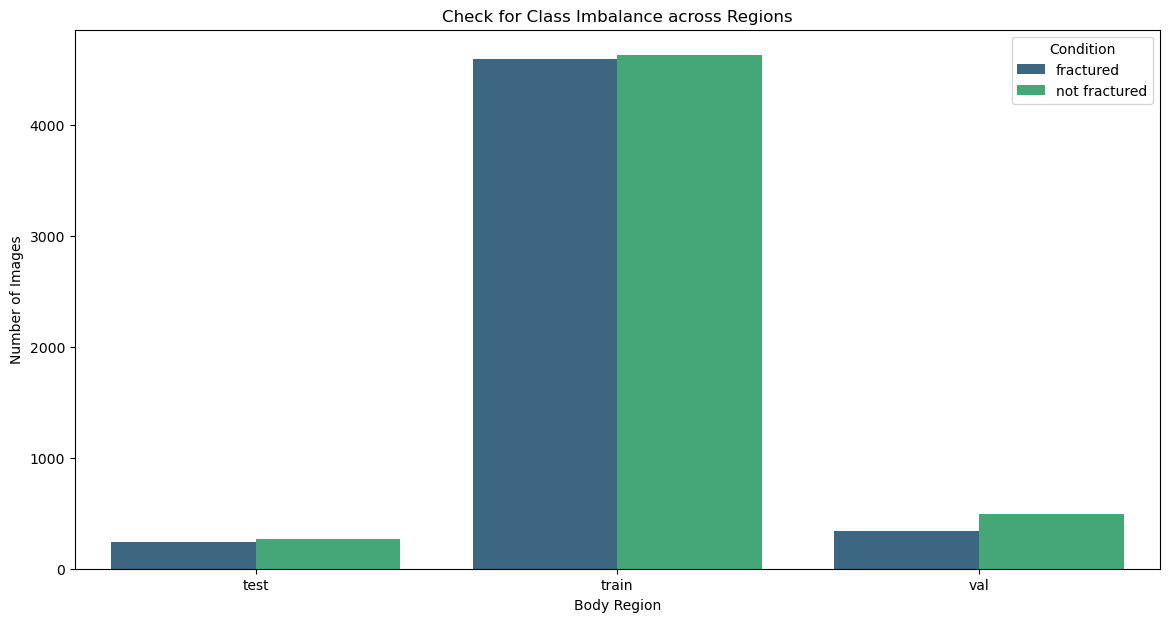

In [35]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Region', hue='Label', palette='viridis')
plt.title('Check for Class Imbalance across Regions')
plt.xlabel('Body Region')
plt.ylabel('Number of Images')
plt.legend(title='Condition')
plt.show()

### Identifying image extensions and how many of each extension are in each file.

In [36]:
from collections import Counter

def check_extensions(path):
    report = {}
    for root, dirs, files in os.walk(path):
        if files:
            extensions = [os.path.splitext(f)[1].lower() for f in files]
            folder_name = os.path.relpath(root, path)
            report[folder_name] = Counter(extensions)
    return report
    
extensions_report = check_extensions(base_path)
for folder, counts in extensions_report.items():
    counts_str = ", ".join([f"{ext}: {count}" for ext, count in counts.items()])
    print(f"{folder:<50} | {counts_str}")

.                                                  | .txt: 1
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\test\fractured | .jpg: 237
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\test\not fractured | .jpg: 267
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\train\fractured | .jpg: 4593
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\train\not fractured | .jpg: 4625
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\val\fractured | .jpg: 336
Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\val\not fractured | .jpg: 490


### Identifying all pixels present in the image within each file

In [37]:
def get_folder_pixels(path):
    folder_reports = []

    for root, dirs, files in os.walk(path):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            folder_name = os.path.relpath(root, path)
            resolutions = []
            
            for img_name in images:
                img_path = os.path.join(root, img_name)
                try:
                    with Image.open(img_path) as img:
                        resolutions.append(img.size) 
                except:
                    continue
            
            if resolutions:
                df_res = pd.DataFrame(resolutions, columns=['Width', 'Height'])
                
                report = {
                    'Folder': folder_name,
                    'Total Images': len(images),
                    'Min Pixels': f"{df_res['Width'].min()}x{df_res['Height'].min()}",
                    'Max Pixels': f"{df_res['Width'].max()}x{df_res['Height'].max()}",
                    'Avg Pixels': f"{int(df_res['Width'].mean())}x{int(df_res['Height'].mean())}"
                }
                folder_reports.append(report)

    return pd.DataFrame(folder_reports)

pixel_report = get_folder_pixels(base_path)
pixel_report

,Folder,Total Images,Min Pixels,Max Pixels,Avg Pixels
0,Bone_Fracture_Binary_Classification\Bone_Fract...,237,224x224,2328x2928,424x485
1,Bone_Fracture_Binary_Classification\Bone_Fract...,267,224x224,2460x2970,557x661
2,Bone_Fracture_Binary_Classification\Bone_Fract...,4593,100x100,4232x5823,289x312
3,Bone_Fracture_Binary_Classification\Bone_Fract...,4625,224x224,2460x3764,257x268
4,Bone_Fracture_Binary_Classification\Bone_Fract...,336,100x100,3000x4403,504x576
5,Bone_Fracture_Binary_Classification\Bone_Fract...,490,224x224,2460x2970,408x467


### Unifying image borders

In [38]:
base_path = r'path_to_your_original_data'  
output_path = r'C:\Users\HP\Downloads\Processed_Dataset'
target_size = (224, 224)
def resize_with_padding(img, size):
    h, w = img.shape[:2]
    sh, sw = size
    
    aspect = w / h
    if aspect > 1: 
        # new_w = sw
        new_h = np.round(new_w / aspect).astype(int)
    else:
        new_h = sh
        new_w = np.round(new_h * aspect).astype(int)
        
    scaled_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    top = (sh - new_h) // 2
    bottom = sh - new_h - top
    left = (sw - new_w) // 2
    right = sw - new_w - left
    
    padded_img = cv2.copyMakeBorder(scaled_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img


for root, dirs, files in os.walk(base_path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if image_files:
        rel_path = os.path.relpath(root, base_path)
        target_dir = os.path.join(output_path, rel_path)
        os.makedirs(target_dir, exist_ok=True)
        
        print(f" {rel_path}( {len(image_files)})")
        
        for img_name in image_files:
            img_path = os.path.join(root, img_name)
            img = cv2.imread(img_path)
            
            if img is not None:
                final_img = resize_with_padding(img, target_size)
                save_name = os.path.splitext(img_name)[0] + ".jpg"
                cv2.imwrite(os.path.join(target_dir, save_name), final_img)

print(f"\n The process was successful! All images are now in size. {target_size} It is in the folder: {output_path}")


 The process was successful! All images are now in size. (224, 224) It is in the folder: C:\Users\HP\Downloads\Processed_Dataset


In [39]:
path_parts = root.split(os.sep)
label = path_parts[-1]    
region = path_parts[-2]  

data_list = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            path_parts = root.split(os.sep)
            label = path_parts[-1]   # fractured أو not fractured
            split_type = path_parts[-2] # train أو test أو val
            region = path_parts[-3] if len(path_parts) > 3 else "Unknown"
            data_list.append({
                'Split': split_type, 
                'Region': region, 
                'Label': label,
                'File_Name': file
            })

## Image Enhancement (CLAHE) and Precise Region Extraction
#### This code adjusts image contrast (to reveal hidden fractions)
#### Fixing the Region problem

In [48]:
import os
import pandas as pd


output_path = r'C:\Users\HP\Downloads\archive (26)\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification'
processed_data = []

for root, dirs, files in os.walk(output_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path_parts = root.split(os.sep)
            
            label = path_parts[-1]
            
            full_path = os.path.join(root, file)
            processed_data.append({
                'Path': full_path,
                'Label': label,
                'Split': path_parts[-2] if len(path_parts) > 2 else "Unknown"
            })

df_final = pd.DataFrame(processed_data)

print("Distribution of categories in the data:")
print(df_final['Label'].value_counts())

Distribution of categories in the data:
Label
not fractured    5382
fractured        5166
Name: count, dtype: int64


## I will use the ResNet50 model, which is the standard in medical image analysis, focusing on Recall metrics.

In [42]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, regularizers 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from PIL import ImageFile

def build_medical_model_1(input_shape=(224, 224, 3)):
    
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), 
        layers.Dense(1, activation='sigmoid') 
    ])
    
   
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_medical_model_1()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [43]:
def build_advanced_medical_model_2(input_shape=(224, 224, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4), 
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid') 
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_advanced_medical_model_2()
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,711,297 (94.27 MB)

 Trainable params: 1,119,233 (4.27 MB)

 Non-trainable params: 23,592,064 (90.00 MB)

In [44]:
def build_deep_medical_model_3(input_shape=(224, 224, 3)):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(), 
        
        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        layers.Dense(64, activation='relu'),
          
        layers.Dense(1, activation='sigmoid') 
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

deep_model = build_deep_medical_model_3()
deep_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,399,105 (100.70 MB)

 Trainable params: 2,803,457 (10.69 MB)

 Non-trainable params: 23,595,648 (90.01 MB)

In [53]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_df_final = df_final[df_final['Split'] == 'train'].copy()
train_df_final['Label'] = train_df_final['Label'].astype(str)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df_final,
    x_col='Path',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=train_df_final,
    x_col='Path',
    y_col='Label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)


deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy'] 
)

try:
    history = deep_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5 
    )
except Exception as e:
    print(f"There is still a mistake: {e}")

Found 7375 validated image filenames belonging to 2 classes.
Found 1843 validated image filenames belonging to 2 classes.
بدء التدريب التجريبي...


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1086s 5s/step - accuracy: 0.6738 - loss: 2.4183 - val_accuracy: 5.4259e-04 - val_loss: 2.8754
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1009s 4s/step - accuracy: 0.8332 - loss: 1.6817 - val_accuracy: 0.0244 - val_loss: 4.0162
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1111s 5s/step - accuracy: 0.8933 - loss: 1.4390 - val_accuracy: 0.1194 - val_loss: 4.0491
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1031s 4s/step - accuracy: 0.9247 - loss: 1.3069 - val_accuracy: 0.1606 - val_loss: 4.2600
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 972s 4s/step - accuracy: 0.9294 - loss: 1.2442 - val_accuracy: 0.1682 - val_loss: 4.4908
نجح التدريب!


Found 504 images belonging to 2 classes.


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step

 ***** (Classification Report) *****
               precision    recall  f1-score   support

    fractured       0.97      0.49      0.66       237
not fractured       0.69      0.99      0.81       267

     accuracy                           0.76       504
    macro avg       0.83      0.74      0.73       504
 weighted avg       0.82      0.76      0.74       504



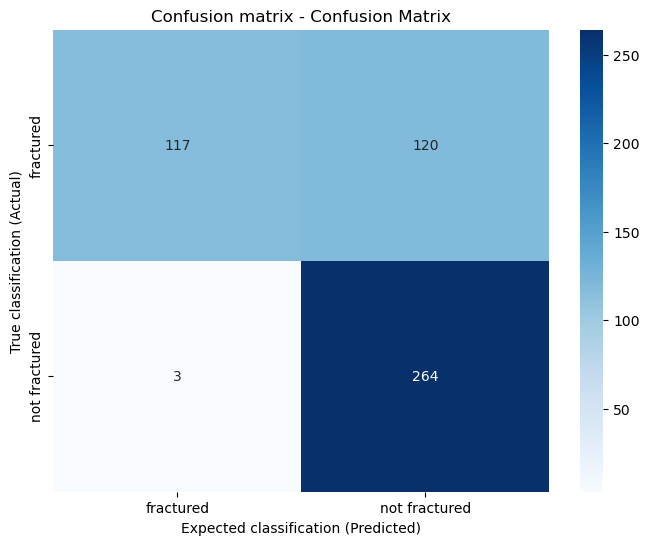

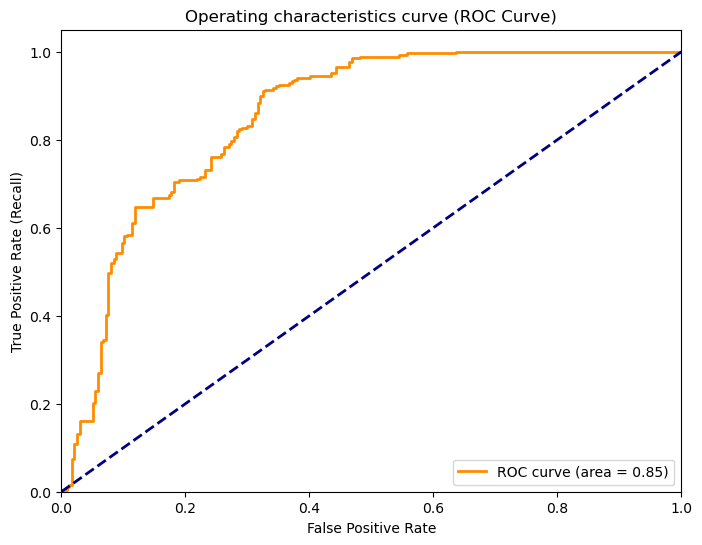

In [54]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

test_dir = r'C:\Users\HP\Downloads\archive (26)\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification\test'
test_datagen = ImageDataGenerator(rescale=1./255) 

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False 
)

def evaluate_medical_model(model, test_gen):
    
    test_gen.reset()
    y_pred_probs = model.predict(test_gen)
    y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
    
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    print(f"\n {'*'*5} (Classification Report) {'*'*5}")
    print(classification_report(y_true, y_pred_classes, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion matrix - Confusion Matrix')
    plt.ylabel('True classification (Actual)')
    plt.xlabel('Expected classification (Predicted)')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Operating characteristics curve (ROC Curve)')
    plt.legend(loc="lower right")
    plt.show()

evaluate_medical_model(deep_model, test_generator)

from sklearn.utils import class_weight
import numpy as np
labels = df_final[df_final['Split'] == 'train']['Label'].map({'fractured': 1, 'not fractured': 0}).values
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(weights))